In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 가설 1. 이용 목적별 만족도 변동성 분석

## 데이터 로드

- 분석은 설문 구조가 통합된 마스터 테이블 기준으로 수행한다.
- 이후 모든 통계 분석 및 시각화는 해당 데이터셋을 기반으로 진행된다.

In [5]:
# 설문 A/B 통합 마스터 테이블 로드
df = pd.read_excel("../data/master_table.xlsx")

## 세그먼트별 응답 비율

In [6]:
ratio = df["cat_01"].value_counts(normalize=True)

print("[세그먼트 응답 비율]")
display(ratio.round(3))

[세그먼트 응답 비율]


cat_01
type_A    0.80
type_B    0.10
type_C    0.07
type_D    0.03
Name: proportion, dtype: float64

- type A 유형의 응답자 비율이 80%로 가장 많음.
- 반면 type D 유형의 응답자 비율은 3%로 가장 적음.
    - 이는 실제 운영 환경에서 type A 유형의 응답자가 가장 많은 것이 반영됨.
    - 설문 데이터를 특정 집단에서 편중되지 않게 받을 수 있는 방안 독려 필요

## 만족도 항목별 비율

In [7]:
score_cols = ["sat_01","sat_02","sat_03","sat_04","sat_05","sat_06"]

mean_table = df.groupby("cat_01")[score_cols].mean().round(3)

print("[만족도 항목별 평균]")
display(mean_table)

[만족도 항목별 평균]


,sat_01,sat_02,sat_03,sat_04,sat_05,sat_06
cat_01,,,,,,
type_A,4.819,4.824,3.814,4.691,4.720,4.721
type_B,4.860,4.950,3.840,4.630,4.760,4.730
type_C,4.857,4.700,3.614,4.800,4.600,4.700
type_D,5.000,3.400,3.867,4.567,4.733,4.700


### 해석 기준 
| 평균 점수 구간        | 해석 레벨  |
| --------------- | ------ |
| **4.50 – 5.00** | 매우 높음  |
| **4.00 – 4.49** | 높음     |ㅡ
| **3.50 – 3.99** | 다소 높음  |
| **3.00 – 3.49** | 보통     |
| **2.00 – 2.99** | 불만족    |
| **1.00 – 1.99** | 매우 불만족 |


- 세그먼트별 평균 만족도는 전반적으로 높은 수준을 유지하였다.
- 단순 평균만으로는 사용자 경험 차이를 충분히 설명하기 어려운 구조가 관찰된다.

## 만족도 항목별 표준편차

In [8]:
std_table = df.groupby("cat_01")[score_cols].std().round(3)

print("[만족도 항목별 표준편차]")
display(std_table)

[만족도 항목별 표준편차]


,sat_01,sat_02,sat_03,sat_04,sat_05,sat_06
cat_01,,,,,,
type_A,0.385,0.385,1.014,0.465,0.452,0.451
type_B,0.349,0.219,1.061,0.485,0.429,0.468
type_C,0.352,0.462,1.026,0.403,0.493,0.462
type_D,0.000,1.133,0.937,0.504,0.450,0.466


### 해석 기준
| 표준편차 범위       | 해석                             |
| ------------- | ------------------------------ |
| **0.0 ~ 0.3** | 응답 편차가 매우 작음     |
| **0.3 ~ 0.6** | 일반적인 변동 수준                     |
| **0.6 ~ 1.0** | 편차가 큰 항목      |
| **1.0 이상**    | 매우 큰 편차 |

## 세그먼트 간 평균 차이

In [10]:
mean_diff = (mean_table.max() - mean_table.min()).round(3)

print("[항목별 평균 차이 폭]")
display(mean_diff)

[항목별 평균 차이 폭]


sat_01    0.181
sat_02    1.550
sat_03    0.253
sat_04    0.233
sat_05    0.160
sat_06    0.030
dtype: float64

- 일부 항목에서 세그먼트 간 평균 차이가 관찰되었다.
- 그러나 해당 차이가 통계적으로 유의한지 검증이 필요하다.

## ANOVA 검정

- 세그먼트 간 평균 만족도 차이가 관찰됨에 따라, 해당 차이가 통계적으로 유의한지 확인하기 위해 ANOVA 검정을 적용하였다.

In [11]:
anova_results = []

for col in score_cols:
    groups = [df[df.cat_01 == g][col] for g in df.cat_01.unique()]
    stat, p = f_oneway(*groups)
    anova_results.append([col, stat, p])

anova_df = pd.DataFrame(anova_results, columns=["metric","F-stat","p-value"])

print("[ANOVA 결과]")
display(anova_df.round(5))

[ANOVA 결과]


,metric,F-stat,p-value
0,sat_01,2.64213,0.04815
1,sat_02,117.71317,0.00000
2,sat_03,0.91568,0.43269
3,sat_04,2.57349,0.05276
4,sat_05,1.88178,0.13094
5,sat_06,0.08278,0.96942


- **F-statistic (F값)**
    - 집단 간 분산 대비 집단 내 분산의 비율로, 평균 차이의 상대적 크기를 나타내는 지표
- **p-value**
    - 관찰된 차이가 우연히 발생했을 확률을 의미하며, 일반적으로 p < 0.05일 경우 통계적으로 유의한 차이로 해석

- ANOVA 검정 결과, sat_02 (운영 및 지원 대응) 항목에서만 세그먼트 간 평균 차이가 통계적으로 유의하게 나타났다.

## 종합 만족도 점수 생성

- 개별 문항 수준 분석을 보완하기 위해 종합 만족도 지표를 생성하였다.

In [12]:
df["overall_score"] = df[score_cols].mean(axis=1)

## 종합 만족도 – Boxplot

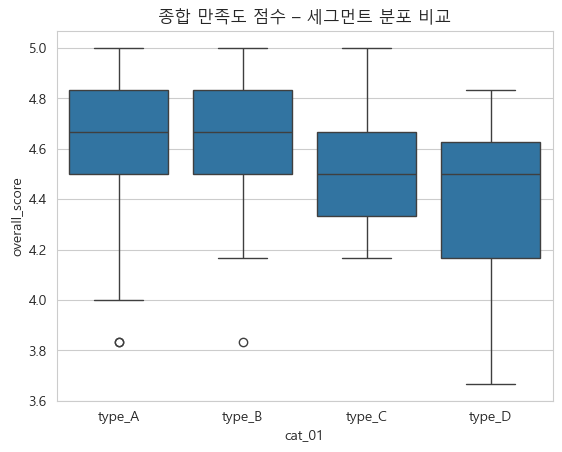

In [13]:
plt.figure()
sns.boxplot(data=df, x="cat_01", y="overall_score")
plt.title("종합 만족도 점수 – 세그먼트 분포 비교")
plt.show()

- 세그먼트 간 중앙값 차이는 제한적으로 나타났다.
- 대부분의 응답이 상위 점수 구간에 집중되는 경향이 관찰된다.

## 종합 만족도 – Stripplot

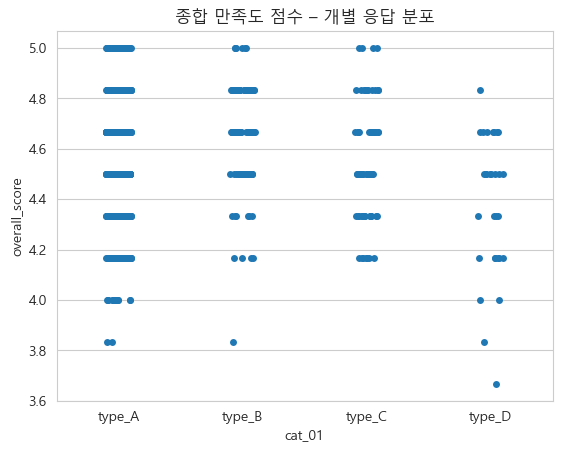

In [14]:
plt.figure()
sns.stripplot(data=df, x="cat_01", y="overall_score", jitter=True)
plt.title("종합 만족도 점수 – 개별 응답 분포")
plt.show()

- 리커트 척도 특성상 응답이 특정 점수 구간에 집중되는 경향이 나타났다.
- 이에 따라 점수 분포의 변동성을 해석하는 데 일정한 한계가 존재한다.

## 운영 및 지원 대응 – Boxplot

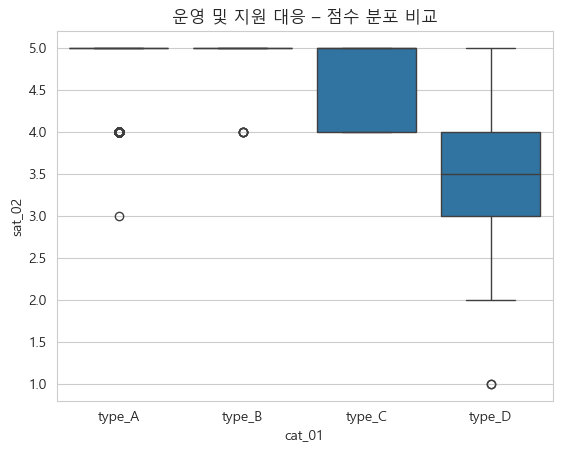

In [15]:
plt.figure()
sns.boxplot(data=df, x="cat_01", y="sat_02")
plt.title("운영 및 지원 대응 – 점수 분포 비교")
plt.show()

- type_D 그룹에서 점수 범위 확장이 뚜렷하게 나타났다.
- 이는 해당 그룹의 사용자 경험이 일관되지 않았음을 의미할 수 있다.
  - ANOVA 유의성 검증 결과와 일관된 패턴

## 운영 및 지원 대응 – Stripplot

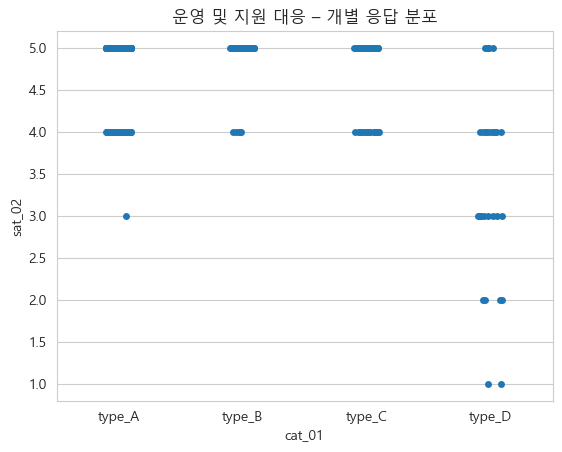

In [ ]:
plt.figure()
sns.stripplot(data=df, x="cat_01", y="sat_02", jitter=True)
plt.title("운영 및 지원 대응 – 개별 응답 분포")
plt.show()

- 특정 그룹(type_D)에서 저점 응답 분포가 상대적으로 증가하였다.
- 각 세그먼트별 평균 차이뿐 아니라 응답 분포 구조 차이도 존재함을 확인하였다.

## 결론

- 분석 결과, 이용 목적(세그먼트) 간 평균 만족도 수준은 전반적으로 유사하게 나타났으나, 항목별 편차 구조에서는 차이가 확인되었다. 
- 특히 운영 지원(operations_support)에 해당하는 항목에서 세그먼트 간 변동성이 가장 크게 나타났으며, ANOVA 검정 결과 해당 항목에서 통계적으로 유의미한 차이가 확인되었다<i>(p < 0.05)</i>. 
- 이는 물리적 환경 요인보다 운영 경험 요인이 세그먼트 간 사용자 경험 차이를 설명하는 핵심 변수일 가능성을 시사한다. 
- 따라서 가설 1은 지지되었다.